In [266]:
import numpy as np
from astropy.io import fits
from astropy.table import Table, Column
import matplotlib.pyplot as plt
from statistics import mode

from jupyterlab.semver import satisfies

In [301]:
# Q 6.1
hdu_list = fits.open('m101.fits')
hdu_list.info()   # 2 HDUs, img data in the first one (index 0), int16

header = hdu_list[0].header
print(header[0:5])   # BITPIX = 16 B/px; 

dat = hdu_list[0].data
print(dat.shape)   # Corresponds to found in info() and header

dtype = dat.dtype
print(dtype, '\n')   # Big-endian, 2-byte (16 bit) signed int

flat = dat.flatten()
max, min, mean, std, median, mode = flat.max(), flat.min(), flat.mean(), flat.std(),np.median(flat), mode(flat)
print(f'Max = {max}, min = {min}, mean = {mean}, std = {std}, median = {median}, mode = {mode}')

Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
SIMPLE  =                    T /FITS header                                     BITPIX  =                   16 /No.Bits per pixel                               NAXIS   =                    2 /No.dimensions                                   NAXIS1  =                  530 /Length X axis                                   NAXIS2  =                  530 /Length Y axis                                   END                                                                                                                                                                                                                                                                                                                                                                                

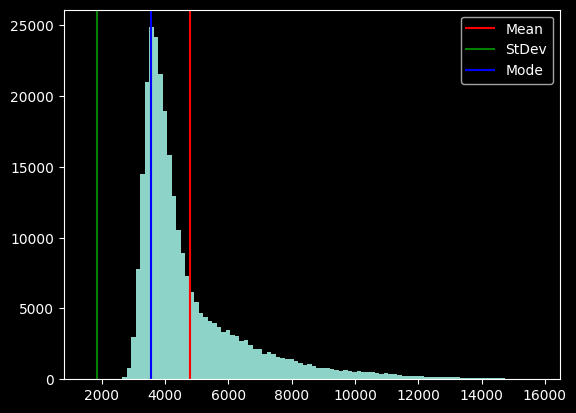

In [302]:
fig, ax = plt.subplots()
ax.hist(flat, bins = 100)
ax.axvline(mean, 
           label = 'Mean',
           color = 'red')
ax.axvline(std, 
           label = 'StDev',
           color = 'green')
ax.axvline(mode,
           label = 'Mode',
           color = 'blue')
ax.legend()
plt.show()

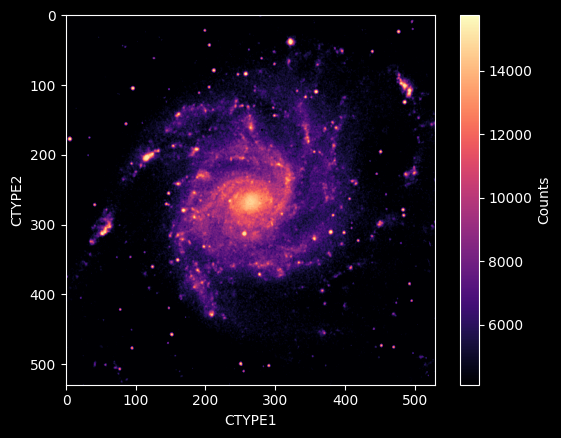

In [303]:
img = np.asarray(dat, dtype = float)

plt.imshow(img, vmin = median, cmap = 'magma')
plt.xlabel('CTYPE1')
plt.ylabel('CTYPE2')
plt.colorbar(label = 'Counts')
plt.show()

In [119]:
header['BUNIT'] = 'Counts'

hdu_list_out = fits.PrimaryHDU(img)
hdu_list_out.header = header
hdu_list_out.writeto('float_m101.fits', overwrite=True, output_verify='ignore')

In [304]:
# Q 6.3 (pending)
noise = dat[50:70, 0:20]
print(noise)
print(noise**2)

x_RMS = ( 1/(20**2)) * sum(sum((noise ** 2)) )**0.5
print(x_RMS)

mean = noise.mean()
std = noise.std()
print(mean, std)

[[3334 3334 3680 3334 3247 2901 3074 3767 3810 3810 3810 3464 3377 3377
  3377 3377 3789 3442 3615 3615]
 [3334 3334 3334 2987 2901 2554 2728 3421 3464 3464 3464 3810 3724 3724
  3377 4070 3789 3442 3269 3269]
 [3161 3507 3507 3161 3074 3074 2901 3247 3291 3291 3291 3637 3724 3724
  3897 3897 3962 3615 3096 3096]
 [3161 3507 3507 3161 3421 3421 3247 3594 3637 3637 3637 3291 3031 3031
  3204 3897 3962 3615 3442 3442]
 [3161 3161 3334 3680 3074 3074 3421 3421 3551 4244 4070 3377 3464 3117
  3291 3637 3529 3529 3702 3356]
 [3507 3507 3334 3680 4114 3421 3421 3421 3551 3551 3377 3377 3117 3464
  3637 3291 3529 3529 3356 3009]
 [3507 3854 3680 3680 3940 3594 3594 3594 3551 3204 3031 3031 2944 3984
  3464 3464 3702 3702 3529 3182]
 [3507 3854 3680 2987 3247 3594 3594 3594 3204 3551 3377 3377 3637 3984
  3464 3464 3356 3356 3529 3182]
 [3291 3984 3637 3637 3204 3551 3551 3897 3551 3897 3897 3551 3810 3810
  3637 3637 3572 3572 3399 3399]
 [2944 3637 3984 3984 3551 3204 3551 3897 3551 3897 389

In [164]:
# Q 6.5 (pending)
noise0 = fits.open('/Users/taiga/Desktop/RUG/2025–26/BlocII/ProgNum/PROGNUM-repo/Task6/noisemap0.fits')
noise1 = fits.open('/Users/taiga/Desktop/RUG/2025–26/BlocII/ProgNum/PROGNUM-repo/Task6/noisemap1.fits')
noise2 = fits.open('/Users/taiga/Desktop/RUG/2025–26/BlocII/ProgNum/PROGNUM-repo/Task6/noisemap2.fits')

dat0 = noise0[0].data
dat1 = noise1[0].data
dat2 = noise2[0].data

std0 = dat0.std()
std1 = dat1.std()
std2 = dat2.std()
print(std0, std1, std2)

[[  8.0587697   -1.07148748  -7.94252166 ...   1.8627231   -0.35151771
   -3.5337107 ]
 [-13.55526968  10.82722034   1.94668037 ...   2.28100433 -14.56981996
    3.17186205]
 [ -5.22192002  -1.12902934  -4.93718543 ...  -2.51274867  14.26655034
   -1.16902669]
 ...
 [  3.96698099  -4.24848048   7.75790014 ...   2.82140355  12.53801726
   -0.94226734]
 [-14.17206419  -9.7223836    2.87151289 ...  20.35030903  -5.96118923
   -6.09171454]
 [ -1.41236052  10.75909443  -5.61589335 ... -13.15620678  10.11301075
  -18.33834386]]
9.98401556679484 10.003955116338458 9.995349488722516


(893, 891)


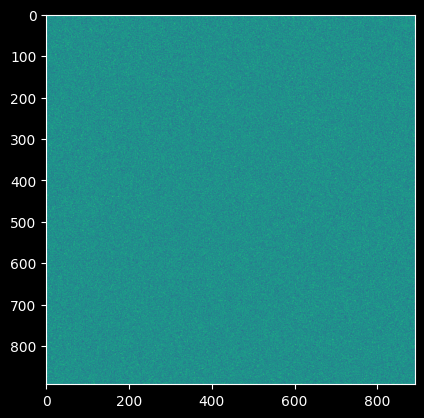

In [305]:
stack = np.stack((dat0, dat1, dat2), axis=0)
noise_mean = np.mean(stack, axis = 0)
print(noise_mean.shape)

plt.imshow(noise_mean)
plt.show()

In [306]:
px_std = []

for x in range(893):
    for y in range(891):
        px_std.append(np.std(stack[:,x,y]))

In [225]:
ar_px_std = np.asarray(px_std)

std_np = noise_mean.std()
std_calc = 1/len(ar_px_std) * ( sum(ar_px_std ** 2) ) ** 0.5
print(std_np, std_calc)

5.773191380233297 0.009146172448391573


In [268]:
# Q 6.6
# Open the FITS file
hdul = fits.open('/Users/taiga/Desktop/RUG/2025–26/BlocII/ProgNum/PROGNUM-repo/Task6/APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
t = Table(hdul[1].data)

In [293]:
starflag = data['STARFLAG'] == 0
aspcapflag = data['ASPCAPFLAG'] == 0
snr = data['SNR'] > 10
g1 = data['GAIAEDR3_PARALLAX'] - data['GAIAEDR3_PARALLAX_ERROR'] > 5
g2 = np.isfinite(data['GAIAEDR3_PHOT_G_MEAN_MAG'])
g3 = np.isfinite(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])
g4 = np.isfinite(data['GAIAEDR3_PHOT_RP_MEAN_MAG'])

DATAFLAG_bool = starflag & aspcapflag & snr & g1 & g2 & g3 & g4
DATAFLAG = DATAFLAG_bool.astype(int)
t.add_column(DATAFLAG, name = 'DATAFLAG')

In [298]:
good_data = data[DATAFLAG_bool]

ABS_MAG = good_data['GAIAEDR3_PHOT_G_MEAN_MAG'] + 5 * np.log10(good_data['GAIAEDR3_PARALLAX']/1000) + 5
